In [2]:
import os
import glob
from enum import Enum

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [3]:
class Channel(Enum):
    Player_1_Worker = 0
    Player_1_Ground = 1
    Player_1_Air = 2
    Player_1_Building = 3
    
    Player_2_Worker = 4
    Player_2_Ground = 5
    Player_2_Air = 6
    Player_2_Building = 7
    
    Resource = 8
    Vision = 9
    Terrain = 10

In [4]:
pred = os.path.join(os.path.split(os.getcwd())[0], "predictions")
predictions_vanilla = glob.glob(os.path.join(pred, 'vanilla', "*.json"))
predictions_kbrs = glob.glob(os.path.join(pred, 'kbrs', "*.json"))
reps = [f"{os.path.basename(pred).split('_')[0]}.rep" for pred in predictions_vanilla]

In [5]:
replay_set = ['36.rep', '212.rep', '438.rep', '522.rep', '1660.rep']
gt_root = os.path.join(os.path.split(os.getcwd())[0], 'data/label/dst')
ground_truth = [
    f for name in replay_set
    for f in glob.glob(os.path.join(gt_root, name, '*.json'))
]

In [6]:
# open json files and load them
predictions_vanilla_data = []

for pred in predictions_vanilla:
    with open(pred, 'r') as f:
        data = json.load(f)
        predictions_vanilla_data.append(data)

predictions_kbrs_data = []
for pred in predictions_kbrs:
    with open(pred, 'r') as f:
        data = json.load(f)
        predictions_kbrs_data.append(data)
        
ground_truth_data = []
for gt in ground_truth:
    with open(gt, 'r') as f:
        data = json.load(f)
        ground_truth_data.append(data)  

In [7]:
annotations_vanilla = []
for pred in predictions_vanilla_data:
    df = pd.DataFrame(pred['annotations'])
    df['replay'] = pred['info']['description'].split(' ')[-1] + '.rep'
    annotations_vanilla.append(df)
annotations_vanilla = pd.concat(annotations_vanilla)
annotations_vanilla = annotations_vanilla[['replay', 'id', 'image_id', 'category_id', 'bbox', 'score', 'area', 'segmentation', 'iscrowd']]

In [8]:
annotations_kbrs = []
for pred in predictions_kbrs_data:
    df = pd.DataFrame(pred['annotations'])
    df['replay'] = pred['info']['description'].split(' ')[-1] + '.rep'
    annotations_kbrs.append(df)
annotations_kbrs = pd.concat(annotations_kbrs)
annotations_kbrs = annotations_kbrs[['replay', 'id', 'image_id', 'category_id', 'bbox', 'score', 'area', 'segmentation', 'iscrowd']]

In [9]:
annotations_ground_truth = []
for gt in ground_truth_data:
    df = pd.DataFrame(gt['annotations'])
    df['replay'] = gt['info']['description'].split(' ')[-1] + '.rep'
    annotations_ground_truth.append(df)
annotations_ground_truth = pd.concat(annotations_ground_truth)
annotations_ground_truth = annotations_ground_truth[['replay', 'id', 'image_id', 'category_id', 'bbox', 'area', 'segmentation', 'iscrowd']]

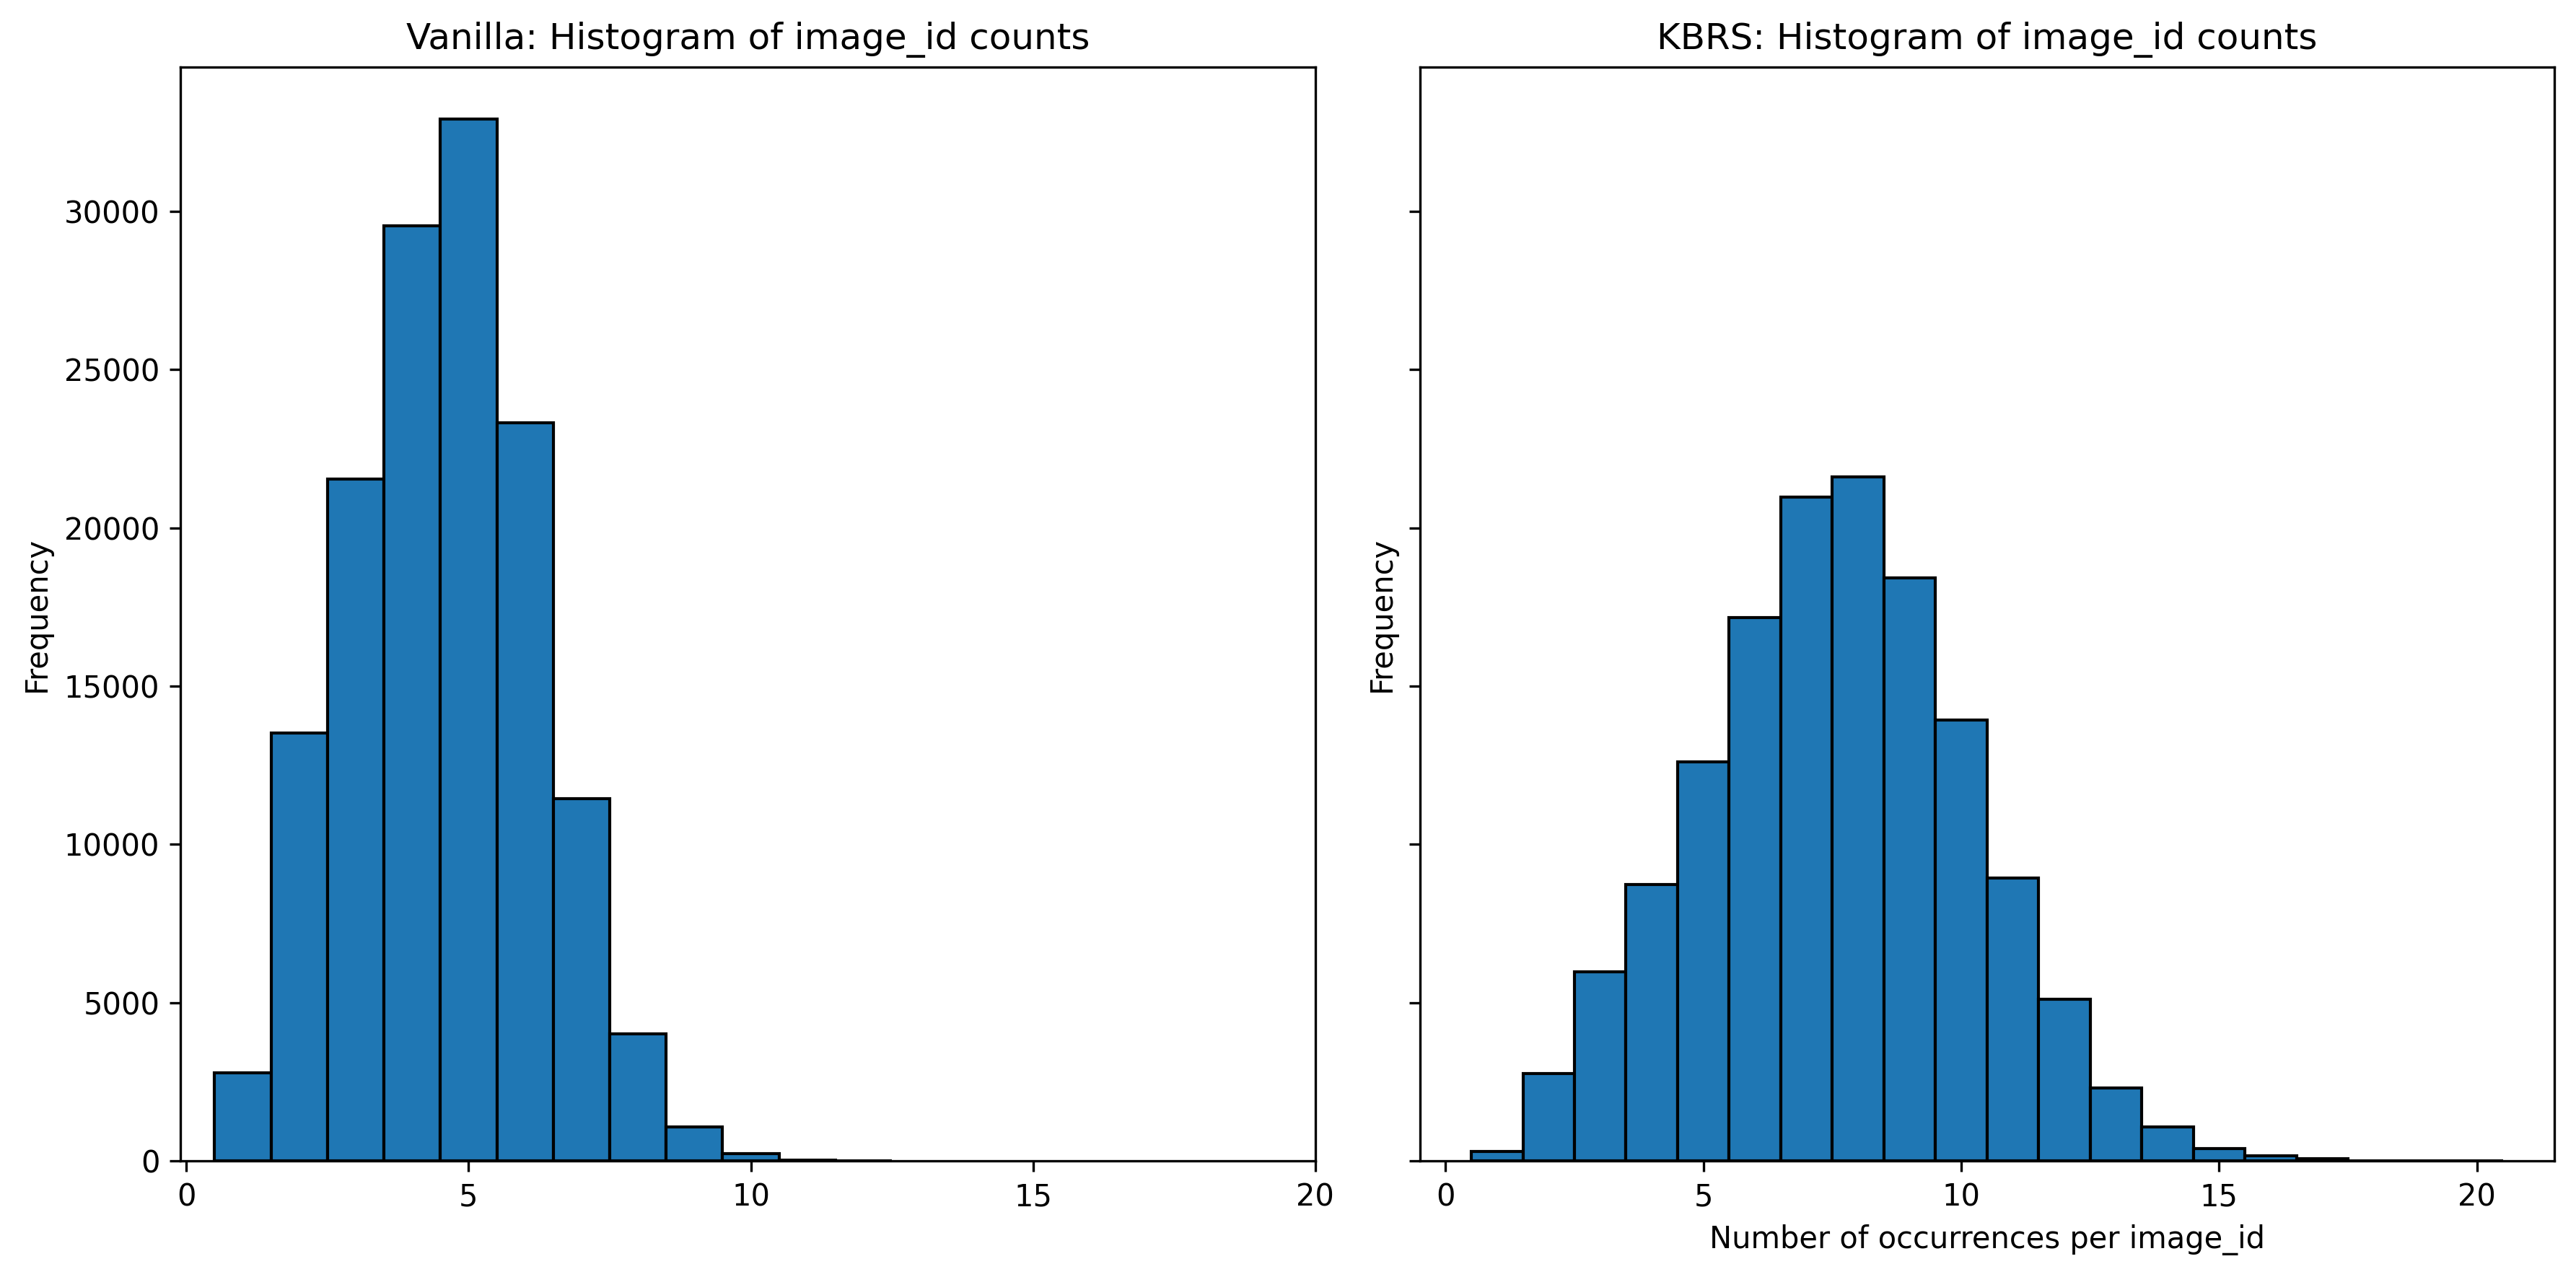

In [10]:
counts_vanilla = annotations_vanilla.groupby(['replay', 'image_id']).size()
counts_kbrs = annotations_kbrs.groupby(['replay', 'image_id']).size()
counts_groundtruth = annotations_ground_truth.groupby(['replay', 'image_id']).size()

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=300, sharey=True)

axes[0].hist(
    counts_vanilla,
    bins=range(1, counts_vanilla.max() + 2),
    edgecolor='black',
    align='left'
)
axes[0].set_ylabel('Frequency')
axes[0].set_title('Vanilla: Histogram of image_id counts')
axes[0].set_xticks(range(0, max(counts_vanilla.max(), counts_kbrs.max()) + 1, 5))

axes[1].hist(
    counts_kbrs,
    bins=range(1, counts_kbrs.max() + 2),
    edgecolor='black',
    align='left'
)
axes[1].set_xlabel('Number of occurrences per image_id')
axes[1].set_ylabel('Frequency')
axes[1].set_title('KBRS: Histogram of image_id counts')
axes[1].set_xticks(range(0, max(counts_vanilla.max(), counts_kbrs.max()) + 1, 5))

# axes[2].hist(
#     counts_groundtruth,
#     bins=range(1, counts_kbrs.max() + 2),
#     edgecolor='black',
#     align='left'
# )
# axes[2].set_xlabel('Number of occurrences per image_id')
# axes[2].set_ylabel('Frequency')
# axes[2].set_title('Grond truth: Histogram of image_id counts')
# axes[2].set_xticks(range(0, max(counts_vanilla.max(), counts_kbrs.max()) + 1, 5))

plt.tight_layout()

plt.show()

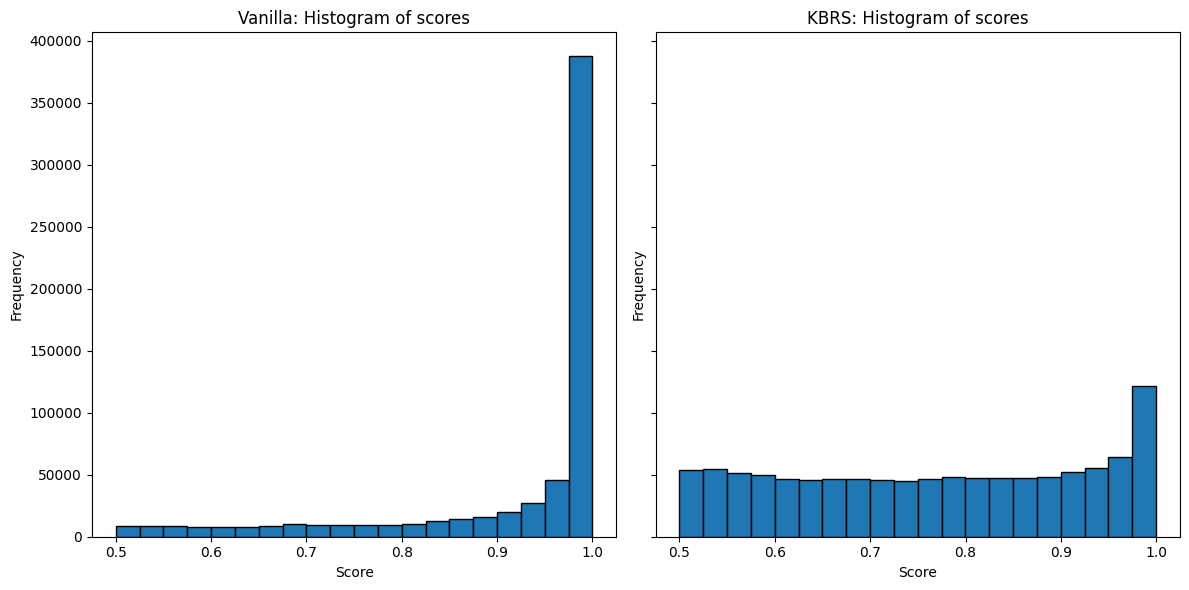

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].hist(annotations_vanilla['score'], bins=20, edgecolor='black')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Vanilla: Histogram of scores')


axes[1].hist(annotations_kbrs['score'], bins=20, edgecolor='black')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('KBRS: Histogram of scores')

plt.tight_layout()
plt.show()

In [12]:
def compute_iou_box(box1, box2):
    # box: [x, y, w, h] → convert to (x1, y1, x2, y2)
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    xi1 = max(x1, x2)
    yi1 = max(y1, y2)
    xi2 = min(x1 + w1, x2 + w2)
    yi2 = min(y1 + h1, y2 + h2)

    inter_area = max(xi2 - xi1, 0) * max(yi2 - yi1, 0)
    union_area = w1 * h1 + w2 * h2 - inter_area

    return inter_area / union_area if union_area > 0 else 0

In [ ]:
import torch
from torchvision.ops import box_iou
import numpy as np
import pandas as pd

def evaluate_iou_fast(gt_df, pred_df, iou_threshold=0.5):
    results = []
    
    # 프레임 단위 key 생성
    keys_gt = set(zip(gt_df['replay'], gt_df['image_id']))
    keys_pred = set(zip(pred_df['replay'], pred_df['image_id']))
    shared_keys = sorted(keys_gt & keys_pred)
    
    for replay, image_id in shared_keys:
        gt_rows = gt_df[(gt_df['replay'] == replay) & (gt_df['image_id'] == image_id)]
        pred_rows = pred_df[(pred_df['replay'] == replay) & (pred_df['image_id'] == image_id)]
        
        if len(gt_rows) == 0 and len(pred_rows) == 0:
            continue

        gt_boxes = torch.tensor(gt_rows['bbox'].tolist(), dtype=torch.float)  # [G, 4]
        pred_boxes = torch.tensor(pred_rows['bbox'].tolist(), dtype=torch.float)  # [P, 4]

        if len(gt_boxes) == 0:
            tp = 0
            fp = len(pred_boxes)
            fn = 0
            ious = []
        elif len(pred_boxes) == 0:
            tp = 0
            fp = 0
            fn = len(gt_boxes)
            ious = []
        else:
            iou_matrix = box_iou(pred_boxes, gt_boxes)  # shape: [P, G]
            matched_gt = set()
            tp = 0
            fp = 0
            ious = []

            for pred_idx in range(iou_matrix.size(0)):
                ious_row = iou_matrix[pred_idx]
                best_iou, best_gt_idx = torch.max(ious_row, dim=0)
                if best_iou >= iou_threshold and best_gt_idx.item() not in matched_gt:
                    tp += 1
                    ious.append(best_iou.item())
                    matched_gt.add(best_gt_idx.item())
                else:
                    fp += 1

            fn = len(gt_boxes) - len(matched_gt)

        precision = tp / (tp + fp) if tp + fp > 0 else 0
        recall = tp / (tp + fn) if tp + fn > 0 else 0

        results.append({
            'replay': replay,
            'image_id': image_id,
            'precision': precision,
            'recall': recall,
            'mean_iou': np.mean(ious) if ious else 0,
            'tp': tp,
            'fp': fp,
            'fn': fn
        })

    return pd.DataFrame(results)

,replay,id,image_id,category_id,bbox,area,segmentation,iscrowd
0,36.rep,1,0,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0
1,36.rep,2,0,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0
2,36.rep,3,0,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0
3,36.rep,4,0,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0
4,36.rep,5,0,1,"[108, 2, 20, 12]",240,"[[108, 2, 128, 2, 128, 14, 108, 14]]",0
...,...,...,...,...,...,...,...,...
130605,1660.rep,130606,26121,1,"[92, 90, 20, 12]",240,"[[92, 90, 112, 90, 112, 102, 92, 102]]",0
130606,1660.rep,130607,26121,1,"[68, 113, 20, 12]",240,"[[68, 113, 88, 113, 88, 125, 68, 125]]",0
130607,1660.rep,130608,26121,1,"[7, 66, 20, 12]",240,"[[7, 66, 27, 66, 27, 78, 7, 78]]",0
130608,1660.rep,130609,26121,1,"[31, 36, 20, 12]",240,"[[31, 36, 51, 36, 51, 48, 31, 48]]",0


In [15]:
results_vanilla = evaluate_iou(annotations_ground_truth.loc[annotations_ground_truth['replay'] == '36.rep'], annotations_vanilla.loc[annotations_vanilla['replay'] == '36.rep'])

In [ ]:
results_kbrs = evaluate_iou(annotations_ground_truth[annotations_ground_truth['replay'] == '36.rep'], annotations_kbrs.loc[annotations_kbrs['replay'] == '36.rep'])

In [ ]:
results_vanilla['model'] = 'vanilla'
results_kbrs['model'] = 'kbrs'

combined_results = pd.concat([results_vanilla, results_kbrs], ignore_index=True)
summary = combined_results.groupby('model')[['precision', 'recall', 'mean_iou']].mean()

summary

In [ ]:
def compute_frame_coverage(bboxes, frame_size=(128, 128)):
    mask = np.zeros(frame_size, dtype=bool)
    for bbox in bboxes:
        x, y, w, h = map(int, bbox)
        x1, y1 = max(x, 0), max(y, 0)
        x2 = min(x + w, frame_size[1])
        y2 = min(y + h, frame_size[0])
        mask[y1:y2, x1:x2] = True
    return np.sum(mask) / (frame_size[0] * frame_size[1])

In [ ]:
def compare_coverage_multiple(gt_df, pred_dict, frame_size=(128, 128)):
    gt_keys = set(zip(gt_df['replay'], gt_df['image_id']))
    all_keys = set(gt_keys)
    for df in pred_dict.values():
        all_keys |= set(zip(df['replay'], df['image_id']))

    result = []

    for key in sorted(all_keys):
        replay, frame_id = key
        gt_bboxes = gt_df[(gt_df['replay'] == replay) & (gt_df['image_id'] == frame_id)]['bbox'].tolist()
        gt_cov = compute_frame_coverage(gt_bboxes, frame_size)

        entry = {
            'replay': replay,
            'image_id': frame_id,
            'gt_coverage': gt_cov,
        }

        for model_name, pred_df in pred_dict.items():
            pred_bboxes = pred_df[(pred_df['replay'] == replay) & (pred_df['image_id'] == frame_id)]['bbox'].tolist()
            pred_cov = compute_frame_coverage(pred_bboxes, frame_size)
            entry[f'{model_name}_coverage'] = pred_cov
            entry[f'{model_name}_diff'] = abs(gt_cov - pred_cov)

        result.append(entry)

    return pd.DataFrame(result)

In [ ]:
coverage_df = compare_coverage_multiple(
    gt_df=annotations_ground_truth,
    pred_dict={
        'vanilla': annotations_vanilla,
        'kbrs': annotations_kbrs
    }
)

KeyboardInterrupt: 

In [42]:
def draw_overview(data, rep_name, frame, ground_truths=None, segmentations_list=None):
    plt.figure(figsize=(6, 6), dpi=300)

    # Terrain & resource
    plt.imshow(data[Channel.Terrain.value] > 0, cmap='Greys', alpha=0.5)
    resource_alpha = np.where(data[Channel.Resource.value] == 1, 1.0, 0.0)
    plt.imshow(data[Channel.Resource.value] == 1, cmap='GnBu', alpha=resource_alpha)

    # Player colors
    p1_cmap = 'Greens'
    p2_cmap = 'Reds'

    # Player 1 & 2 - worker
    player_1_worker_alpha = np.where(data[Channel.Player_1_Worker.value] != 0, 1.0, 0.0)
    player_2_worker_alpha = np.where(data[Channel.Player_2_Worker.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Worker.value] != 0, cmap=p1_cmap, alpha=player_1_worker_alpha)
    plt.imshow(data[Channel.Player_2_Worker.value] != 0, cmap=p2_cmap, alpha=player_2_worker_alpha)

    # Player 1 & 2 - ground
    player_1_ground_alpha = np.where(data[Channel.Player_1_Ground.value] != 0, 1.0, 0.0)
    player_2_ground_alpha = np.where(data[Channel.Player_2_Ground.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Ground.value] != 0, cmap=p1_cmap, alpha=player_1_ground_alpha)
    plt.imshow(data[Channel.Player_2_Ground.value] != 0, cmap=p2_cmap, alpha=player_2_ground_alpha)

    # Player 1 & 2 - air
    player_1_air_alpha = np.where(data[Channel.Player_1_Air.value] != 0, 1.0, 0.0)
    player_2_air_alpha = np.where(data[Channel.Player_2_Air.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Air.value] != 0, cmap=p1_cmap, alpha=player_1_air_alpha)
    plt.imshow(data[Channel.Player_2_Air.value] != 0, cmap=p2_cmap, alpha=player_2_air_alpha)

    # Player 1 & 2 - building
    player_1_building_alpha = np.where(data[Channel.Player_1_Building.value] != 0, 1.0, 0.0)
    player_2_building_alpha = np.where(data[Channel.Player_2_Building.value] != 0, 1.0, 0.0)
    plt.imshow(data[Channel.Player_1_Building.value] != 0, cmap=p1_cmap, alpha=player_1_building_alpha)
    plt.imshow(data[Channel.Player_2_Building.value] != 0, cmap=p2_cmap, alpha=player_2_building_alpha)

    # Vision mask
    vision_alpha = np.where(data[Channel.Vision.value] == 1, 0.0, 0.9)
    plt.imshow(np.zeros_like(data[Channel.Vision.value]), cmap='Greys_r', alpha=vision_alpha)

    ax = plt.gca()

    # --- Segmentation Overlays (여러 개) ---
    if segmentations_list is not None:
        colors = ['red', 'blue']  # 두 개 세그먼트용 색상
        for seg_idx, segmentations in enumerate(segmentations_list):
            for seg in segmentations:
                coords = np.array(seg[0]).reshape(-1, 2)
                polygon = patches.Polygon(
                    coords,
                    linewidth=1.5,
                    edgecolor=colors[seg_idx % len(colors)],
                    facecolor='none'
                )
                ax.add_patch(polygon)

    # --- Ground Truth Overlay ---
    if ground_truths is not None:
        gt_color = 'green'
        for gt in ground_truths:
            coords = np.array(gt[0]).reshape(-1, 2)
            polygon = patches.Polygon(
                coords,
                linewidth=1.5,
                edgecolor=gt_color,
                facecolor='none',
                linestyle='--'
            )
            ax.add_patch(polygon)

    plt.axis('off')
    plt.tight_layout()

    os.makedirs(f'figures/{rep_name}', exist_ok=True)
    plt.savefig(
        f'figures/{rep_name}/{rep_name}_{frame}_Overview.png',
        bbox_inches='tight',
        pad_inches=0
    )
    # plt.show()


In [43]:
common_ids = np.intersect1d(annotations_vanilla['image_id'].unique(), annotations_kbrs['image_id'].unique())
random_ids = np.random.choice(common_ids, replace=False)
print(f"Randomly selected image_ids: {random_ids}")

prediction_vanilla_results = annotations_vanilla.loc[annotations_vanilla['image_id'] == random_ids]
prediction_kbrs_results = annotations_kbrs.loc[annotations_kbrs['image_id'] == random_ids]
print(f"Number of predictions for {random_ids} - vannila: {len(prediction_vanilla_results)} kbrs: {len(prediction_kbrs_results)}")

images = predictions_vanilla_data[0]['images']
image_path = next((item for item in images if item['id'] == random_ids), None)

input_root = os.path.join(os.path.split(os.getcwd())[0], "data", "input", "dst")
input_path = os.path.join(input_root, image_path['file_name'])
input_numpy = np.load(input_path)

rep_name, frame_npy = image_path['file_name'].split('/')

ground_truth_root = os.path.join(os.path.split(os.getcwd())[0], "data", "label", "dst")
ground_truth_path = os.path.join(ground_truth_root, rep_name, 'all_correct.json')
ground_truth_all_correct = json.load(open(ground_truth_path, 'r'))

df_gt = pd.DataFrame(ground_truth_all_correct['annotations'])
ground_truths = df_gt.loc[df_gt['image_id'] == random_ids]

Randomly selected image_ids: 11475
Number of predictions for 11475 - vannila: 21 kbrs: 50


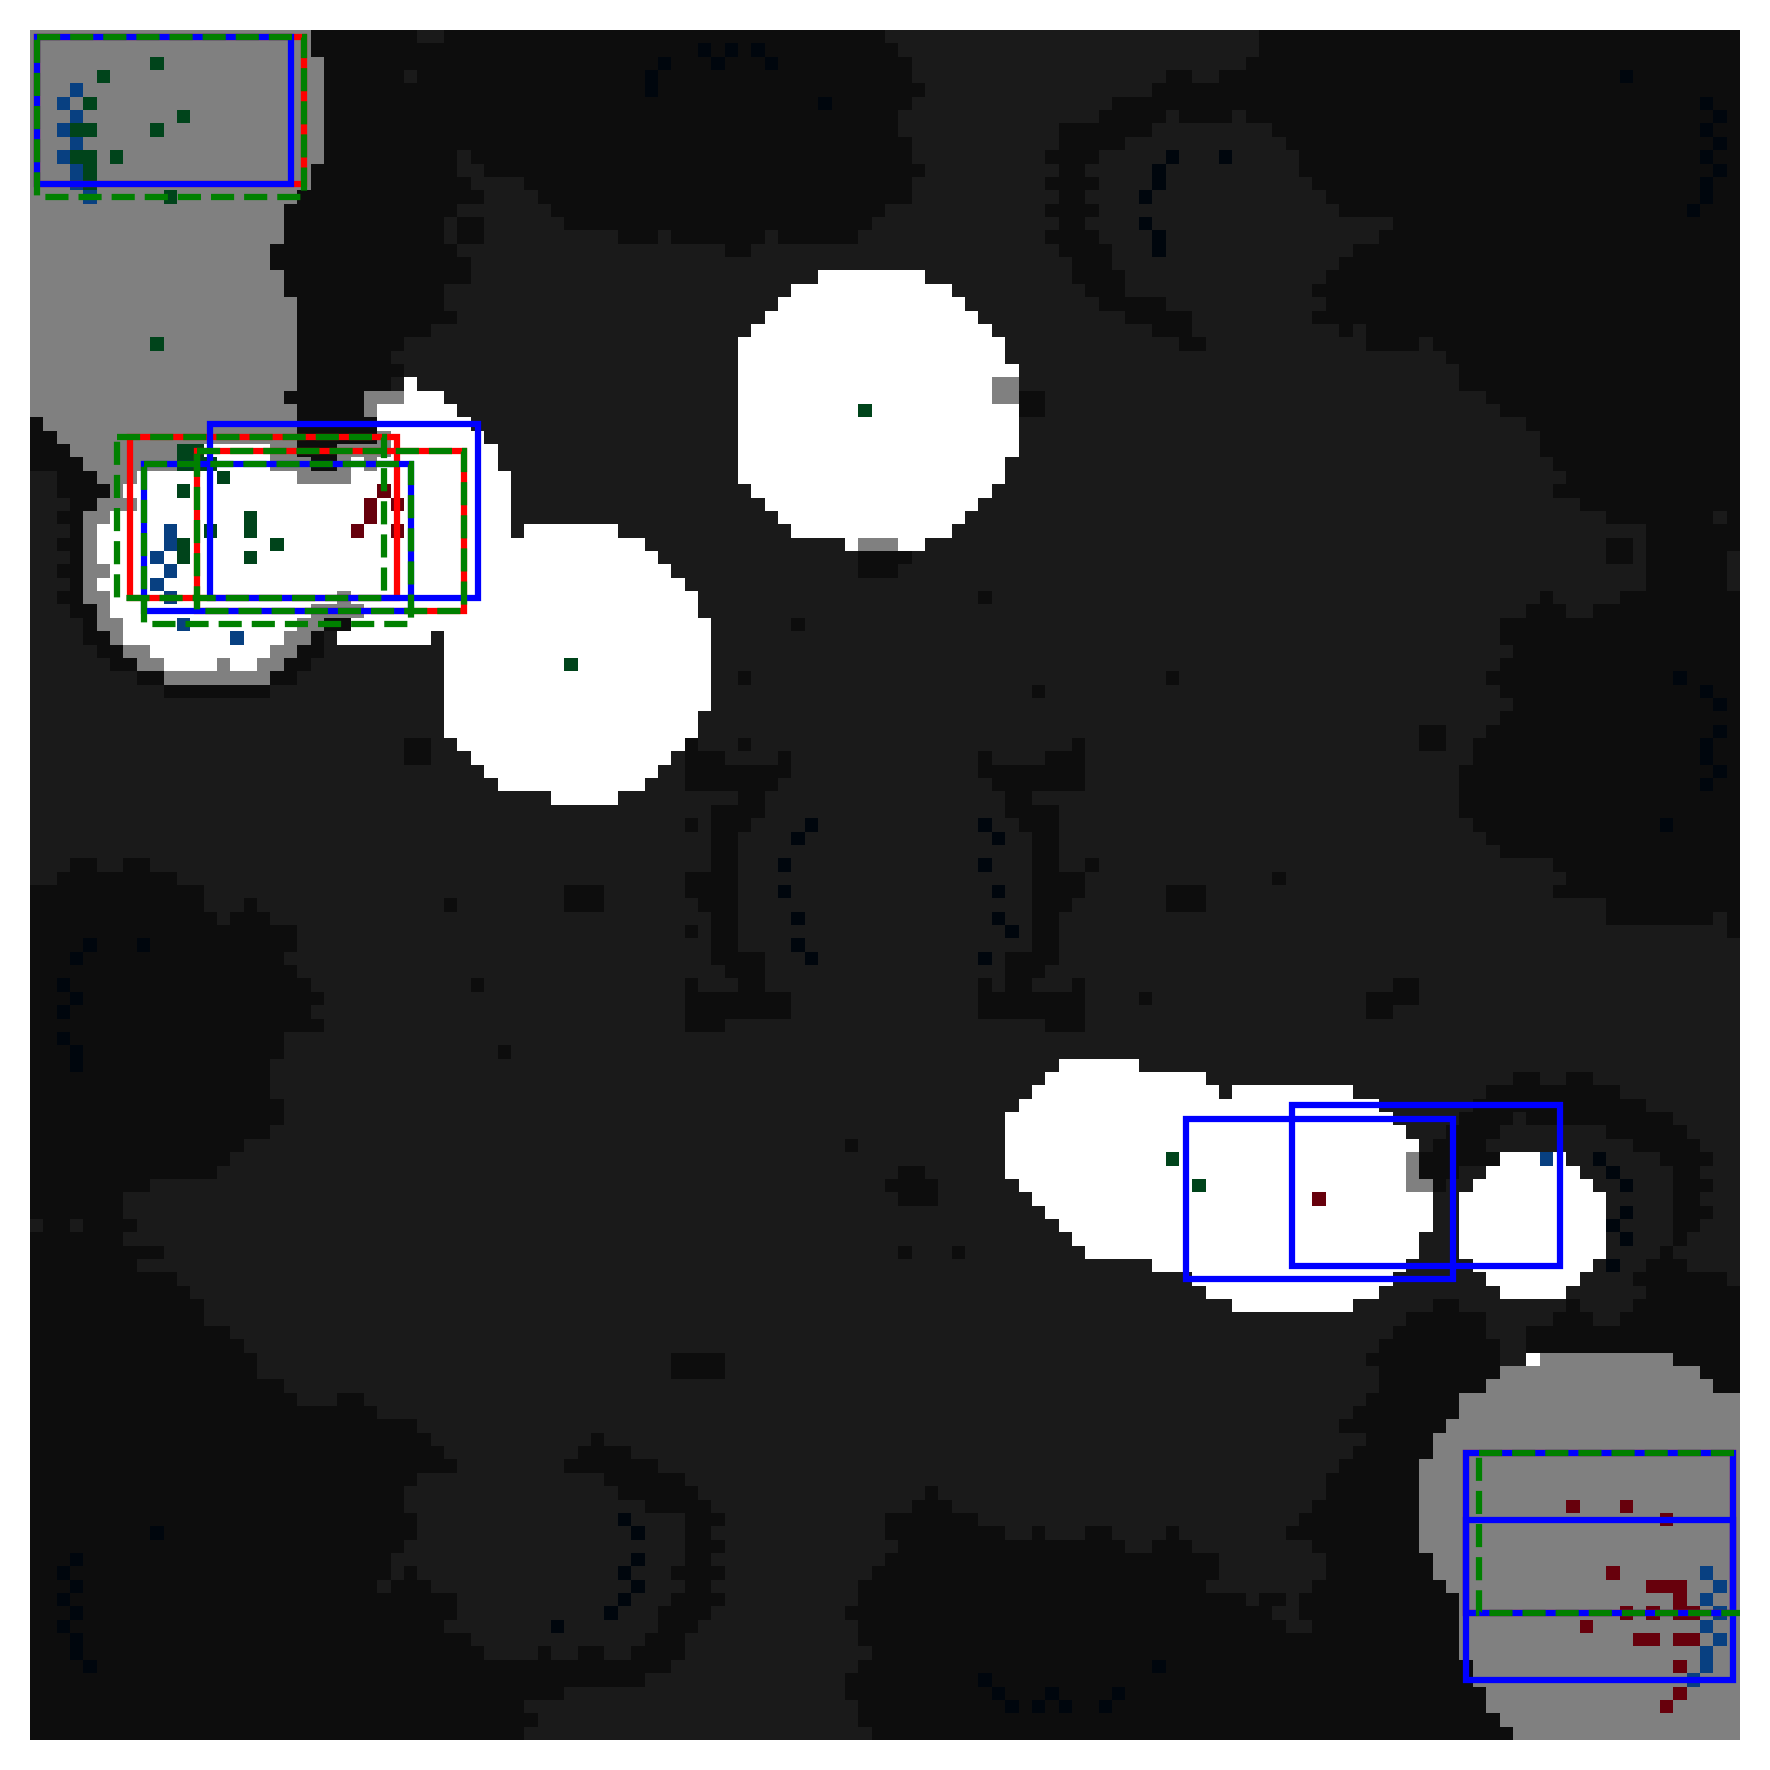

In [70]:
draw_overview(input_numpy,
              rep_name,
              frame_npy.split('.')[0], 
              ground_truths=ground_truths['segmentation'],
              segmentations_list=[prediction_vanilla_results['segmentation'].tolist(), prediction_kbrs_results['segmentation']])